In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'


from AI4AO import PyramidWFS, DeformableMirror

from mmengine import Config
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

In [2]:
imat_data = np.load(r"../Data/Rama/Rama_imats2.npz")
iMat_modal = imat_data["iMat_modal"]
iMat_zonal = imat_data["iMat_zonal"]
pyrMap = imat_data["pupils"]

M2C = np.load(r"../Data/Rama/M2C.npy")
# M2C = np.eye(iMat_zonal.shape[0])
M2C = torch.from_numpy(M2C).to(device = device, dtype = torch.float32)


# _COORDS = ((24, 30), (529, 32), (530, 524), (31, 530))
_COORDS = ((27, 31), (529, 31), (529, 527), (27, 527))
pupil_size = 36
pupil_separation = 6
pyrImSizeX = 560
pyrImSizeY = 560

temp_crop = np.zeros((4, pupil_size + pupil_separation * 2, pupil_size + pupil_separation * 2))
temp_full = test = np.zeros((pyrImSizeX,pyrImSizeY))

iMatCrop = np.zeros((iMat_modal.shape[0], 2*pupil_size + pupil_separation * 4, 2 * pupil_size + pupil_separation * 4))

for i in range(iMat_modal.shape[0]):
    temp_full[pyrMap != 0] = iMat_modal[i]
    for j, (x,y) in enumerate(_COORDS):
        temp_crop[j] = temp_full[x - pupil_separation - pupil_size//2:x + pupil_size//2 + pupil_separation, y - pupil_separation - pupil_size//2:y + pupil_size//2 + pupil_separation]
    tiled = np.block([
        [temp_crop[0], temp_crop[3]],
        [temp_crop[1], temp_crop[2]]
    ])
    iMatCrop[i] = tiled

iMat_bench = torch.from_numpy(iMatCrop).to(device=device, dtype = torch.float32)

reference_frame = iMat_bench.std(dim = 0)
reference_frame = (reference_frame > reference_frame.max() * 0.02).to(device=device, dtype = torch.float32)
reference_frame /= reference_frame.sum()

In [ ]:
WFSParams = dict(
    {
        "Nres":36,
        "sampling":96/36,
        "D": 0.6,
        "useNoise": False,
        "Modulation": 3,
        "Wavelength": 635e-9
    }
)

In [11]:
wfs = PyramidWFS(WFSParams, device)

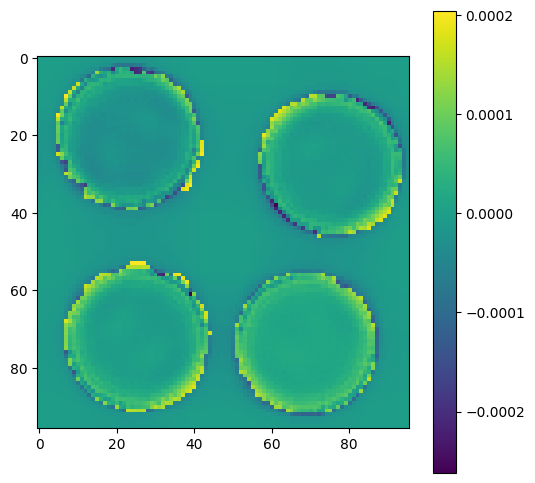

In [12]:
"""
Trains the MaskGenerator neural network to match a target mask pattern.
Generates live plots and saves intermediate mask states into a GIF.

Args:
    maskGenerator (nn.Module): Neural network to generate the mask.
    uv_coords (Tensor): 2D coordinates input to the mask generator.
    mask (Tensor): Target mask used for loss computation.
    loss (function): Loss function to optimize.
    TrainRunNb (int): Number of training iterations.
    optimizer (torch.optim.Optimizer): Optimizer used for training.
    device (str): Device for computation.

Returns:
    None
"""
final_train_loss = 0

TrainRunNb = 200
loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))


img = ax.imshow(reference_frame.cpu().detach().numpy())
fig.colorbar(img)
plt.show()

optimizer = torch.optim.AdamW(wfs.parameters(), 2e-3, fused = True)
wfs.train()

for u in range(0,TrainRunNb) :
    

    optimizer.zero_grad()
    
    wfs.BuildMask()

    wfs.BuildReferenceIntensity() 

    digital_image = wfs.reference_intensity * 1e5
    

    l = loss(reference_frame * 1e5,digital_image)

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((reference_frame - wfs.reference_intensity).cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    



In [13]:
DMParams = dict(
    {
        "Nactuator": 11,
        "Nmodes": 50,
        "moffatParam": 2,
        "signedAmplitude": -5e-6,
        "MechCoupling": 0.36,
        "FlipLeftRight": False,
        "FlipTopBottom": False
    }
)

dm = DeformableMirror(WFSParams,
                    DMParams,
                    device=device,
                    offset_to_fit_number_of_actuators=0.1)


wfs.BuildReferenceIntensity()
dm.RoughCalibration(wfs, iMat_bench, M2C)

Total number of actuators: 97
Best configuration found to be: 
Rotation angle: 45.0
Sign: Possitive
Flip left-right: False
Flip top-bottom: True

Updating values in the DM


In [14]:
ref_phase = torch.nn.Parameter(torch.zeros(*wfs.pupil.shape, device = device, dtype = torch.float32))
ref_pupil = torch.nn.Parameter(torch.ones(*wfs.pupil.shape, device = device, dtype = torch.float32))

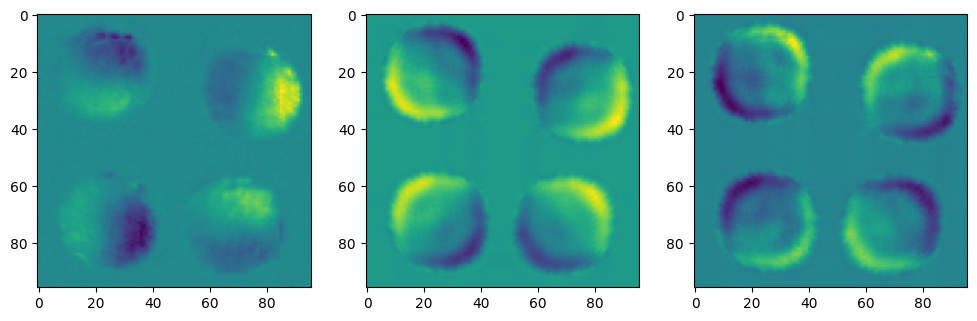

In [15]:
index = list(range(0,96,1))
target = iMat_bench[index]

modes = dm(M2C[:,index].T)
amp = 1e-2

wfs.BuildInteractionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)
digital_image = wfs.iMat

idx = 3
plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(target[idx].cpu().numpy())

plt.subplot(132)
plt.imshow(digital_image[idx].cpu().detach().numpy())

plt.subplot(133)
plt.imshow((target - digital_image)[idx].cpu().detach().numpy())

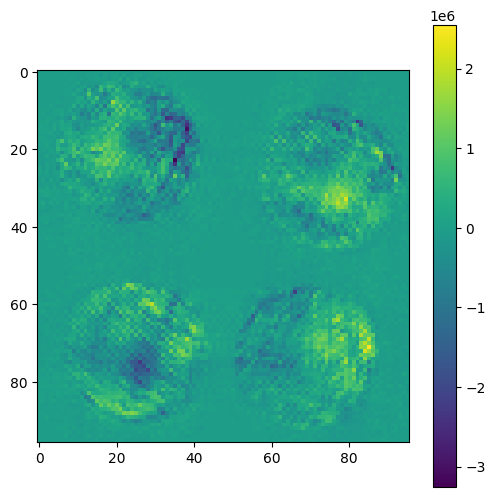

########################################
loss = 0.01135
########################################
({'rotationAngle': 64.16549682617188, 'shiftX': -0.020218559106190997, 'shiftY': -0.0008146079257130623, 'anamorphosisAngle': -74.42224884033203, 'tangentialScaling': 11.725908517837524, 'radialScaling': 13.25378268957138}, {'moffatParam': 0.2977011799812317, 'signedAmplitude': 2.8403367196006e-06, 'MechCoupling': 0.7078467011451721, 'FlipLeftRight': True, 'FlipTopBottom': False, 'offset_to_fit_number_of_actuators': 0.1})


In [19]:
TrainRunNb = 300

loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))

img = ax.imshow(target[4].cpu().detach().numpy())
fig.colorbar(img)

original_positons = dm.anamorphosis_coordinates(dm.actuator_positions)
original_positons = dm.rotate_coordinates(original_positons)


warmup_iters = TrainRunNb // 2
lr_start = -10
lr_end = -2

optimizer = torch.optim.AdamW(  [{"params": dm.parameters(), "lr": 1e-2},
                                {"params": [ref_phase, ref_pupil], "lr": 10**lr_start},
                                {"params": wfs.parameters(), "lr": 1e-3}],
                                fused=True
                                )


wfs.reference_intensity = None

for u in range(0,TrainRunNb) :

    if u < warmup_iters:
        alpha = u / warmup_iters
        optimizer.param_groups[1]["lr"] = 10**(
            lr_start + alpha * (lr_end - lr_start)
        )
    if u == warmup_iters:
        optimizer.param_groups[1]["lr"] = 10**lr_end
    
    optimizer.zero_grad()
    with torch.no_grad():
        wfs.BuildMask()
    
    modes = dm(M2C[:,index].T)

    wfs.BuildInteractionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

    digital_image = wfs.iMat
    
    l = ((target - digital_image)**2).sum()

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((target - digital_image)[4].cpu().detach().numpy()*1e10)
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.5)

        print("#"*40)
        print(f'loss = {l.item():.5f}')
        print("#"*40)
    
print(dm.GetMisreg())

transformed_positons = dm.anamorphosis_coordinates(dm.actuator_positions)
transformed_positons = dm.rotate_coordinates(transformed_positons)

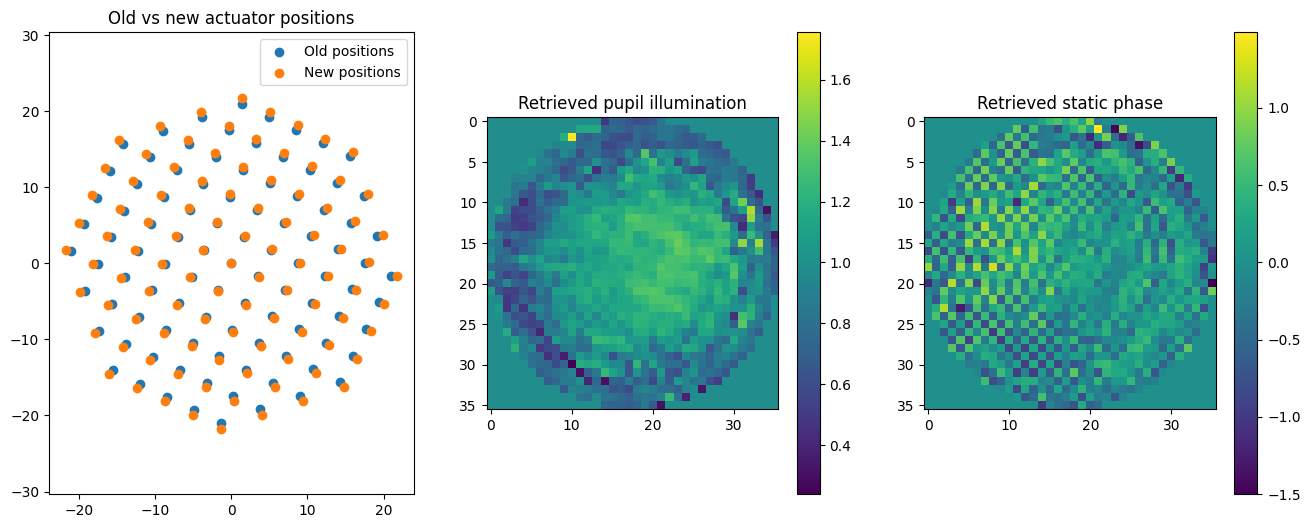

In [20]:
plt.figure(figsize=(16,6))
plt.subplot(131)
plt.title("Old vs new actuator positions")
plt.scatter(original_positons[:,0].cpu().detach(), original_positons[:,1].cpu().detach())
plt.scatter(transformed_positons[:,0].cpu().detach(), transformed_positons[:,1].cpu().detach())
plt.legend(['Old positions', 'New positions'])
plt.axis('equal')
plt.subplot(132)
plt.title('Retrieved pupil illumination')
plt.imshow(ref_pupil.cpu().detach())
plt.colorbar()
plt.subplot(133)
plt.title('Retrieved static phase')
plt.imshow(ref_phase.cpu().detach())
plt.colorbar()

In [21]:
modes = dm(M2C.T)

with torch.no_grad():
    wfs.BuildReconstructionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

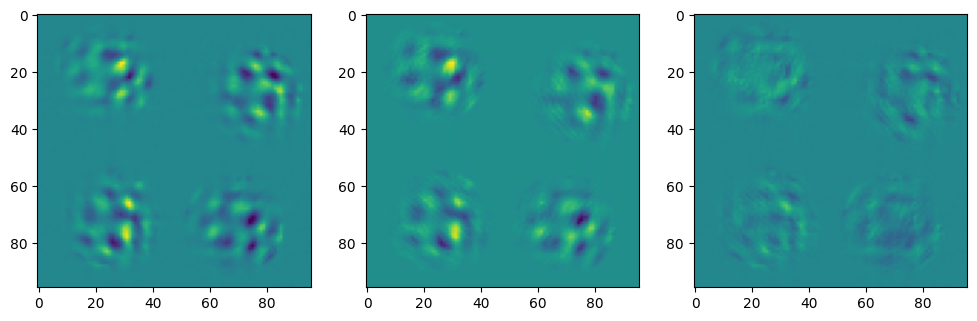

In [22]:
idx = 57
plt.figure(figsize = (12,4))
plt.subplot(131)
plt.imshow((iMat_bench)[idx].cpu().detach().numpy())
plt.subplot(132)
plt.imshow((wfs.iMat)[idx].view_as(reference_frame).cpu().detach().numpy())
plt.subplot(133)
plt.imshow((iMat_bench[idx] - (wfs.iMat)[idx].view_as(reference_frame)).cpu().detach().numpy(), vmin=(iMat_bench)[idx].cpu().detach().numpy().min(), vmax=(iMat_bench)[idx].cpu().detach().numpy().max())

In [23]:
with torch.no_grad():
    cov = iMat_bench.flatten(start_dim = -2) @ wfs.reconstructionMatrix

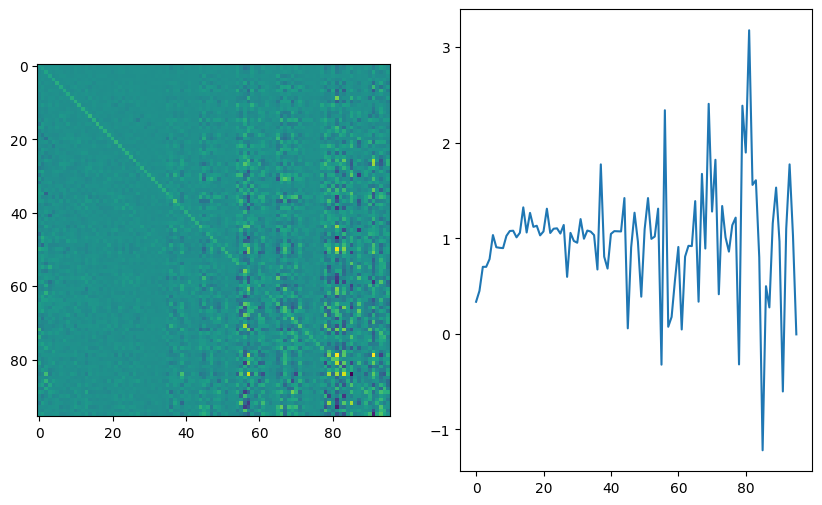

In [24]:
plt.figure(figsize=(10,6))
plt.subplot(121)
plt.imshow(cov.cpu().detach())
plt.subplot(122)
plt.plot(torch.diag(cov).cpu().detach())

In [25]:
PATH_WFS = "../Data/Rama/RamaWFS.pth"
wfs.SaveCalibration(PATH_WFS)

PATH_DM = "../Data/Rama/RamaDM.pth"
dm.SaveCalibration(PATH_DM)

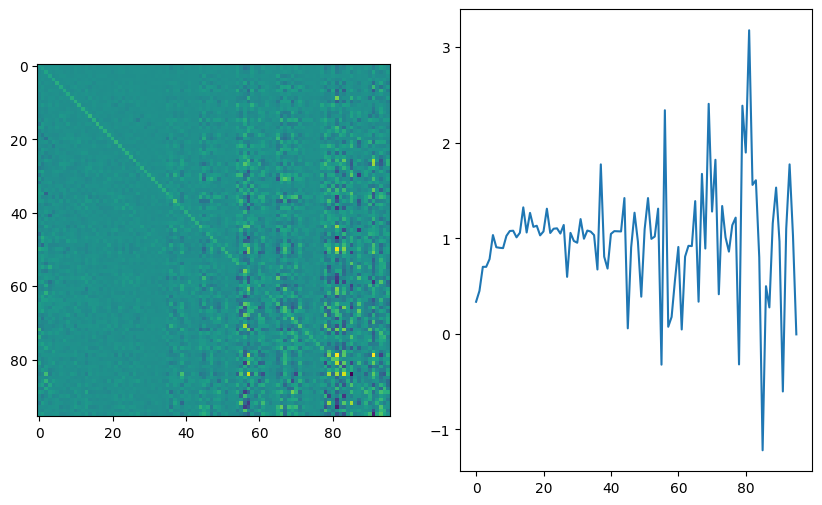

In [27]:
wfs = PyramidWFS(WFSParams, device)
wfs.LoadCalibration(PATH_WFS)
wfs.eval()

dm = DeformableMirror(WFSParams,
                    DMParams,
                    device=device)
dm.LoadCalibration(PATH_DM)
dm.eval()

modes = dm(M2C.T)

with torch.no_grad():
    wfs.BuildReconstructionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

with torch.no_grad():
    cov = iMat_bench.flatten(start_dim = -2) @ wfs.reconstructionMatrix

plt.figure(figsize=(10,6))
plt.subplot(121)
plt.imshow(cov.cpu().detach())
plt.subplot(122)
plt.plot(torch.diag(cov).cpu().detach())

In [ ]:
def untile_pyramid_image(
    tiled,
    coords,
    full_shape=(560, 560),
    pupil_size=36,
    pupil_separation=5,

):
    """
    Reconstruct the full pyramid image from a stitched corner image.

    Parameters
    ----------
    tiled : ndarray
        Stitched image of shape
        (2*(pupil_size+2*pupil_separation),
         2*(pupil_size+2*pupil_separation))

    full_shape : tuple
        Shape of the output full image.

    pupil_size : int
        Size of each pupil.

    pupil_separation : int
        Padding around each pupil.

    coords : list of tuple
        Centers of the four pupils.

    Returns
    -------
    full : ndarray
        Full-sized image with zeros outside the extracted regions.
    """

    crop_size = pupil_size + 2 * pupil_separation

    full = np.zeros(full_shape, dtype=tiled.dtype)

    # Split the stitched image
    crops = [
        tiled[:crop_size, :crop_size],          # top-left  -> crop 0
        tiled[crop_size:, :crop_size],          # bottom-left -> crop 1
        tiled[crop_size:, crop_size:],          # bottom-right -> crop 2
        tiled[:crop_size, crop_size:],          # top-right -> crop 3
    ]

    for crop, (x, y) in zip(crops, coords):
        full[
            x - pupil_separation - pupil_size // 2 : x + pupil_size // 2 + pupil_separation,
            y - pupil_separation - pupil_size // 2 : y + pupil_size // 2 + pupil_separation,
        ] = crop

    return full

In [ ]:
synth_iMat = wfs.iMat.cpu().detach().numpy()

synth_iMat_to_bench = np.zeros_like(iMat_modal)

synth_iMat_full = np.zeros((pyrImSizeX, pyrImSizeY, synth_iMat.shape[-1]))
for i in range(synth_iMat.shape[-1]):
    test = untile_pyramid_image(
        synth_iMat[:,:,i],
        _COORDS,
        full_shape=(560, 560),
        pupil_size=pupil_size,
        pupil_separation=pupil_separation)
    
    synth_iMat_to_bench[i] = test[pyrMap != 0]

# np.save("synth_iMat_v2.npy", synth_iMat_to_bench)